In [4]:
!pip install -q scikeras

!pip install "scikit-learn<1.6"
!pip install --upgrade xgboost lightgbm skorch


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

from sklearn.model_selection import RandomizedSearchCV
from scikeras.wrappers import KerasClassifier

np.random.seed(42)
tf.random.set_seed(42)

In [6]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# fm.fontManager.addfont("times.ttf")
fm.fontManager.addfont("times.ttf")




fm._load_fontmanager(try_read_cache=False)

print([f.name for f in fm.fontManager.ttflist if "Times" in f.name])

['Times New Roman']


In [7]:

import matplotlib as mpl

mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['font.weight'] = 'bold'
mpl.rcParams['axes.labelweight'] = 'bold'
mpl.rcParams['axes.titleweight'] = 'bold'
mpl.rcParams['axes.titlesize'] = 15
mpl.rcParams['axes.labelsize'] = 15
mpl.rcParams['xtick.labelsize'] = 15
mpl.rcParams['ytick.labelsize'] = 15
mpl.rcParams['legend.fontsize'] = 15
mpl.rcParams['font.size'] = 15

In [8]:
(X_train, y_train), (X_test, y_test) = \
    keras.datasets.fashion_mnist.load_data()

print("Training images:", X_train.shape)
print("Training labels:", y_train.shape)
print("Testing images :", X_test.shape)
print("Testing labels :", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Testing images : (10000, 28, 28)
Testing labels : (10000,)


In [9]:
class_names = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot"
]

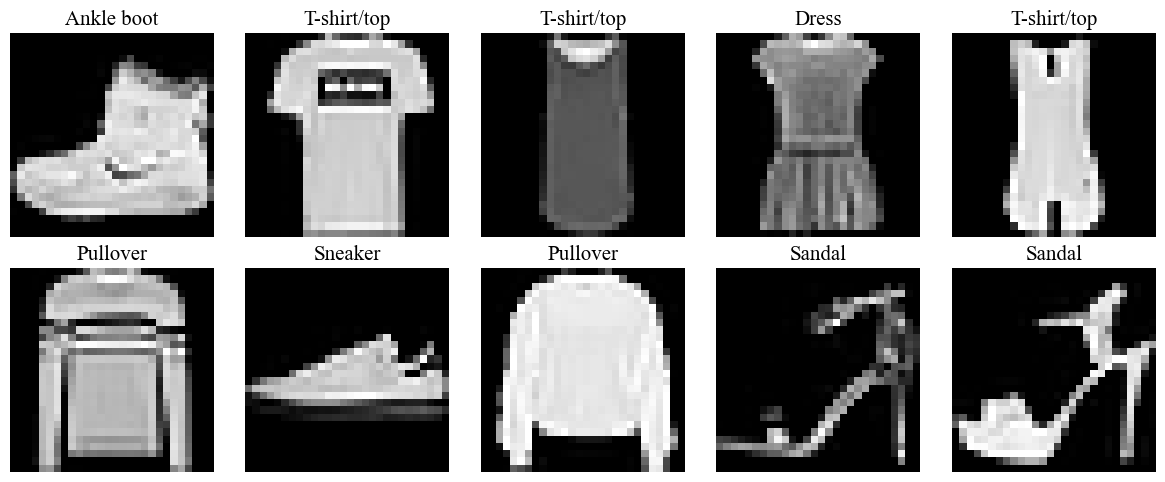

In [65]:
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")

plt.tight_layout()
plt.savefig(
    "classes.eps",
    format="eps",
    dpi = 50,
    bbox_inches="tight"
)
plt.show()

In [11]:
# The sample images show the ten categories represented in the Fashion-MNIST dataset. Each image is a 28×28 grayscale representation of a clothing item.

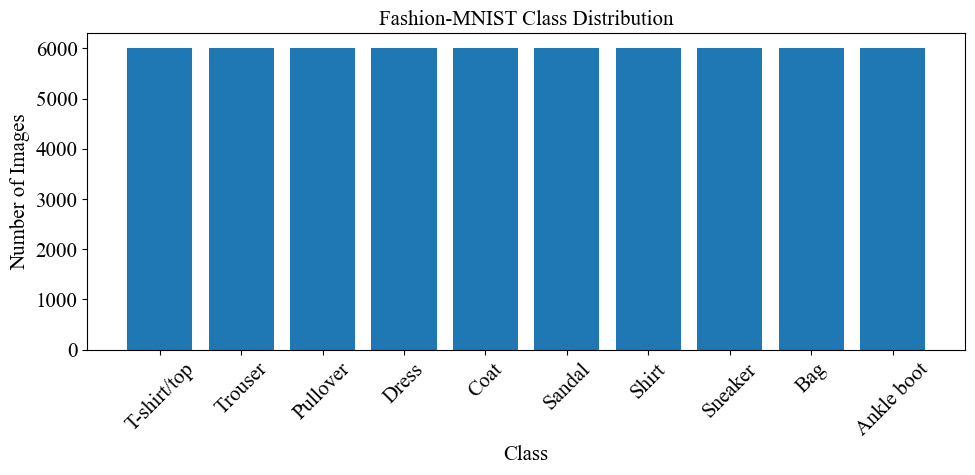

T-shirt/top    : 6000
Trouser        : 6000
Pullover       : 6000
Dress          : 6000
Coat           : 6000
Sandal         : 6000
Shirt          : 6000
Sneaker        : 6000
Bag            : 6000
Ankle boot     : 6000


In [12]:
classes, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(10, 5))
plt.bar(class_names, counts)
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.title("Fashion-MNIST Class Distribution")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(
    "class_distribution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

for name, count in zip(class_names, counts):
    print(f"{name:15s}: {count}")

In [13]:
# The training dataset contains an equal number of samples for all ten classes. Hence, the dataset is balanced and does not require class-weight adjustment.

In [14]:
print("Before preprocessing:")
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

# Flatten 28x28 images into 784-dimensional vectors
X_train_flat = X_train.reshape(X_train.shape[0], -1).astype("float32")
X_test_flat = X_test.reshape(X_test.shape[0], -1).astype("float32")

# Normalize pixel values
X_train_flat /= 255.0
X_test_flat /= 255.0

# One-hot encoding
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat = keras.utils.to_categorical(y_test, 10)

print("\nAfter preprocessing:")
print("X_train:", X_train_flat.shape)
print("X_test :", X_test_flat.shape)
print("y_train:", y_train_cat.shape)
print("y_test :", y_test_cat.shape)

Before preprocessing:
X_train: (60000, 28, 28)
X_test : (10000, 28, 28)

After preprocessing:
X_train: (60000, 784)
X_test : (10000, 784)
y_train: (60000, 10)
y_test : (10000, 10)


In [15]:
baseline_model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation="relu"),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

baseline_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
start_time = time.time()

history = baseline_model.fit(
    X_train_flat,
    y_train_cat,
    validation_split=0.2,
    epochs=20,
    batch_size=32,
    verbose=1
)

baseline_training_time = time.time() - start_time

print(f"\nTraining Time: {baseline_training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 23s 12ms/step - accuracy: 0.8175 - loss: 0.5132 - val_accuracy: 0.8435 - val_loss: 0.4275
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.8633 - loss: 0.3760 - val_accuracy: 0.8628 - val_loss: 0.3750
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8751 - loss: 0.3382 - val_accuracy: 0.8698 - val_loss: 0.3545
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8839 - loss: 0.3128 - val_accuracy: 0.8748 - val_loss: 0.3386
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8900 - loss: 0.2932 - val_accuracy: 0.8743 - val_loss: 0.3441
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8966 - loss: 0.2754 - val_accuracy: 0.8710 - val_loss: 0.3496
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9017 - loss: 0.2639 - val_accuracy: 0.8753 - val_loss: 0.3432
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9052 - loss: 0.250

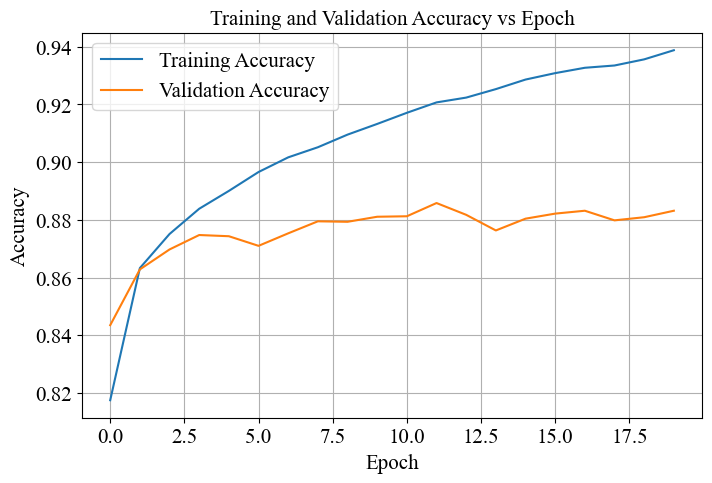

In [17]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy vs Epoch")
plt.legend()
plt.grid(True)
plt.savefig(
    "train_val_acc_vs_epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [18]:
# Training and validation accuracy increase during the initial epochs, indicating that the MLP successfully learns discriminative patterns from the Fashion-MNIST images. The difference between the curves can be used to identify possible overfitting.

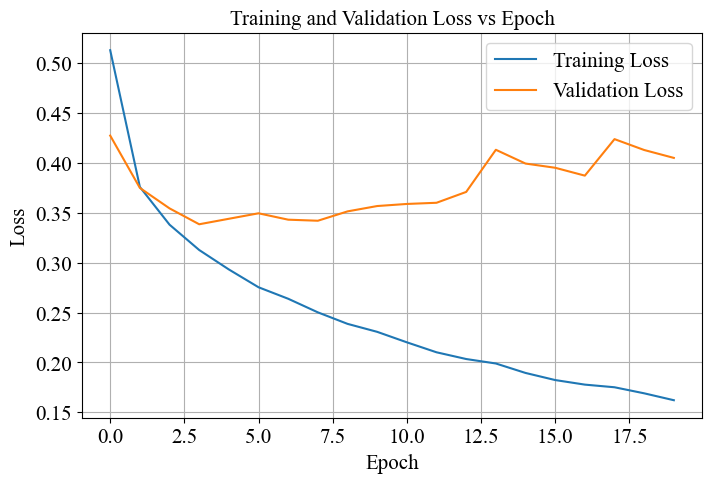

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss vs Epoch")
plt.legend()
plt.grid(True)
plt.savefig(
    "train_val_loss_vs_epoch.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [20]:
# Training loss decreases as the network learns the classification task. Validation loss indicates how well the learned parameters generalize to unseen validation samples.

In [21]:
y_prob = baseline_model.predict(X_test_flat)
y_pred = np.argmax(y_prob, axis=1)

baseline_accuracy = accuracy_score(y_test, y_pred)
baseline_precision = precision_score(
    y_test, y_pred, average="weighted"
)
baseline_recall = recall_score(
    y_test, y_pred, average="weighted"
)
baseline_f1 = f1_score(
    y_test, y_pred, average="weighted"
)

print(f"Accuracy : {baseline_accuracy:.4f}")
print(f"Precision: {baseline_precision:.4f}")
print(f"Recall   : {baseline_recall:.4f}")
print(f"F1-score : {baseline_f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8757
Precision: 0.8775
Recall   : 0.8757
F1-score : 0.8758


In [22]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.85      0.77      0.81      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.82      0.74      0.78      1000
       Dress       0.89      0.89      0.89      1000
        Coat       0.76      0.82      0.79      1000
      Sandal       0.98      0.95      0.97      1000
       Shirt       0.67      0.72      0.70      1000
     Sneaker       0.92      0.97      0.95      1000
         Bag       0.93      0.98      0.95      1000
  Ankle boot       0.96      0.93      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



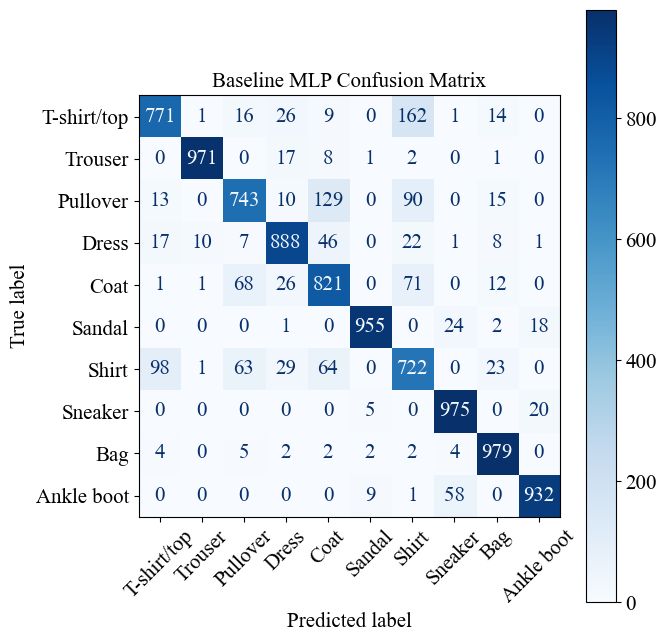

In [66]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
plt.title("Baseline MLP Confusion Matrix")
plt.gcf().set_size_inches(7, 7)
plt.tight_layout()
plt.savefig(
    "baseline_confusion_matrix.eps",
    format="eps",

    bbox_inches="tight"
)
plt.show()

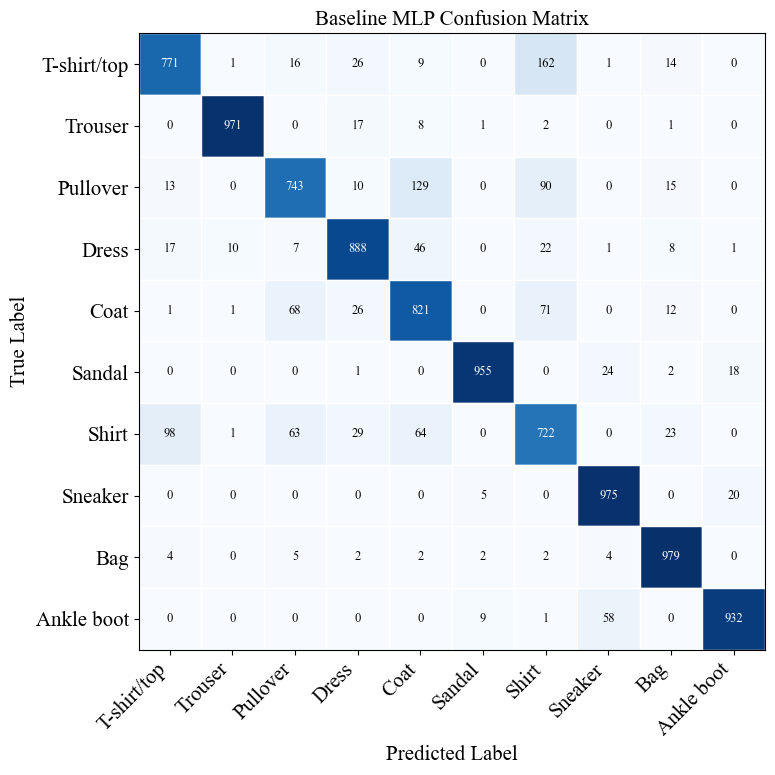

In [24]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(8, 8))

# Draw each confusion-matrix cell as a VECTOR rectangle
max_val = cm.max()

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):

        intensity = cm[i, j] / max_val

        rect = plt.Rectangle(
            (j, i),
            1,
            1,
            facecolor=plt.cm.Blues(intensity),
            edgecolor="white"
        )

        ax.add_patch(rect)

        text_color = "white" if intensity > 0.5 else "black"

        ax.text(
            j + 0.5,
            i + 0.5,
            str(cm[i, j]),
            ha="center",
            va="center",
            color=text_color,
            fontsize=9
        )

ax.set_xlim(0, len(class_names))
ax.set_ylim(len(class_names), 0)

ax.set_xticks(np.arange(len(class_names)) + 0.5)
ax.set_yticks(np.arange(len(class_names)) + 0.5)

ax.set_xticklabels(
    class_names,
    rotation=45,
    ha="right"
)

ax.set_yticklabels(class_names)

ax.set_xlabel("Predicted Label")
ax.set_ylabel("True Label")
ax.set_title("Baseline MLP Confusion Matrix")

plt.tight_layout()

plt.savefig(
    "baseline_confusion_matrix.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)

plt.show()

In [25]:
# The confusion matrix shows that most Fashion-MNIST samples are correctly classified along the diagonal. Misclassifications mainly occur between visually similar clothing categories.

In [26]:
def create_model(
    hidden_layers=2,
    hidden_neurons=128,
    learning_rate=0.001,
    optimizer="adam",
    activation="relu",
    dropout_rate=0.0
):
    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(
            layers.Dense(
                hidden_neurons,
                activation=activation
            )
        )

        if dropout_rate > 0:
            model.add(
                layers.Dropout(dropout_rate)
            )

    model.add(
        layers.Dense(
            10,
            activation="softmax"
        )
    )

    if optimizer == "adam":
        opt = keras.optimizers.Adam(
            learning_rate=learning_rate
        )

    elif optimizer == "sgd":
        opt = keras.optimizers.SGD(
            learning_rate=learning_rate
        )

    else:
        opt = keras.optimizers.RMSprop(
            learning_rate=learning_rate
        )

    model.compile(
        optimizer=opt,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [27]:
keras_classifier = KerasClassifier(
    model=create_model,
    verbose=0
)

In [28]:
param_distributions = {
    "model__hidden_layers": [1, 2, 3],
    "model__hidden_neurons": [32, 64, 128, 256],
    "model__learning_rate": [0.1, 0.01, 0.001],
    "model__optimizer": ["sgd", "adam", "rmsprop"],
    "model__activation": ["relu", "tanh", "sigmoid"],
    "model__dropout_rate": [0.0, 0.2, 0.5],
    "batch_size": [16, 32, 64, 128],
    "epochs": [10, 20, 30]
}

In [29]:
# random_search = RandomizedSearchCV(
#     estimator=keras_classifier,
#     param_distributions=param_distributions,
#     n_iter=10,
#     cv=5,
#     scoring="accuracy",
#     verbose=2,
#     random_state=42,
#     n_jobs=1,
#     return_train_score=True
# )

# start_time = time.time()

# random_search.fit(
#     X_train_flat,
#     y_train
# )

# search_time = time.time() - start_time

# print(f"\nSearch Time: {search_time:.2f} seconds")

In [30]:
# Best Cross-Validation Accuracy:
# 0.88895

# Best Hyperparameters:
# model__optimizer: rmsprop
# model__learning_rate: 0.001
# model__hidden_neurons: 128
# model__hidden_layers: 3
# model__dropout_rate: 0.2
# model__activation: tanh
# epochs: 30
# batch_size: 32

# Hidden Layers : 3
# Hidden Neurons: 128
# Learning Rate : 0.001
# Optimizer     : rmsprop
# Activation    : tanh
# Dropout       : 0.2
# Batch Size    : 32
# Epochs        : 30

In [31]:
# print("Best Cross-Validation Accuracy:")
# print(random_search.best_score_)

# print("\nBest Hyperparameters:")

# for parameter, value in random_search.best_params_.items():
#     print(f"{parameter}: {value}")

In [32]:
# search_results = pd.DataFrame(
#     random_search.cv_results_
# )

# columns = [
#     "rank_test_score",
#     "mean_test_score",
#     "std_test_score",
#     "param_model__hidden_layers",
#     "param_model__hidden_neurons",
#     "param_model__learning_rate",
#     "param_model__optimizer",
#     "param_model__activation",
#     "param_model__dropout_rate",
#     "param_batch_size",
#     "param_epochs"
# ]

# search_results[columns].sort_values(
#     "rank_test_score"
# ).head(10)

In [33]:
def create_model(
    neurons1=128,
    neurons2=64,
    learning_rate=0.001,
    dropout_rate=0.0
):
    model = keras.Sequential([
        layers.Input(shape=(784,)),

        layers.Dense(neurons1, activation="relu"),

        layers.Dropout(dropout_rate),

        layers.Dense(neurons2, activation="relu"),

        layers.Dense(10, activation="softmax")
    ])

    optimizer = keras.optimizers.Adam(
        learning_rate=learning_rate
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [34]:
keras_classifier = KerasClassifier(
    model=create_model,
    verbose=0
)

In [35]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__neurons1": [128, 256],
    "model__neurons2": [64, 128],
    "model__learning_rate": [0.0005, 0.001],
    "model__dropout_rate": [0.0, 0.2],
    "batch_size": [32],
    "epochs": [20]
}

In [36]:
# sorted_results = search_results.sort_values(
#     "mean_test_score",
#     ascending=False
# ).reset_index(drop=True)

# plt.figure(figsize=(10, 5))

# plt.bar(
#     range(len(sorted_results)),
#     sorted_results["mean_test_score"]
# )

# plt.xlabel("Hyperparameter Configuration")
# plt.ylabel("Mean Cross-Validation Accuracy")
# plt.title("Randomized Search Hyperparameter Results")
# plt.xticks(range(len(sorted_results)))
# plt.grid(axis="y")
# plt.show()

In [37]:
# grid_search = GridSearchCV(
#     estimator=keras_classifier,
#     param_grid=param_grid,
#     cv=5,
#     scoring="accuracy",
#     verbose=2,
#     n_jobs=1,
#     return_train_score=True
# )

# start_time = time.time()

# grid_search.fit(
#     X_train_flat,
#     y_train
# )

# grid_search_time = time.time() - start_time

# print(f"\nGrid Search Time: {grid_search_time:.2f} seconds")

In [39]:
# best = grid_search.best_params_
# best

In [40]:
# best parameters - grid search

# {'batch_size': 32,
#  'epochs': 20,
#  'model__dropout_rate': 0.2,
#  'model__learning_rate': 0.0005,
#  'model__neurons1': 256,
#  'model__neurons2': 64}

In [41]:
# best = grid_search.best_params_
best={'batch_size': 32,
 'epochs': 20,
 'model__dropout_rate': 0.2,
 'model__learning_rate': 0.0005,
 'model__neurons1': 256,
 'model__neurons2': 64}

best_neurons1 = best["model__neurons1"]
best_neurons2 = best["model__neurons2"]
best_lr = best["model__learning_rate"]
best_dropout = best["model__dropout_rate"]
best_batch_size = best["batch_size"]
best_epochs = best["epochs"]

# These were fixed during Grid Search
best_optimizer = "Adam"
best_activation = "ReLU"
best_hidden_layers = 2

print("Hidden Layers       :", best_hidden_layers)
print("Hidden Layer 1      :", best_neurons1)
print("Hidden Layer 2      :", best_neurons2)
print("Learning Rate       :", best_lr)
print("Optimizer           :", best_optimizer)
print("Activation Function :", best_activation)
print("Dropout             :", best_dropout)
print("Batch Size          :", best_batch_size)
print("Epochs              :", best_epochs)

Hidden Layers       : 2
Hidden Layer 1      : 256
Hidden Layer 2      : 64
Learning Rate       : 0.0005
Optimizer           : Adam
Activation Function : ReLU
Dropout             : 0.2
Batch Size          : 32
Epochs              : 20


In [42]:
# best = random_search.best_params_

# best_hidden_layers = best["model__hidden_layers"]
# best_hidden_neurons = best["model__hidden_neurons"]
# best_lr = best["model__learning_rate"]
# best_optimizer = best["model__optimizer"]
# best_activation = best["model__activation"]
# best_dropout = best["model__dropout_rate"]
# best_batch_size = best["batch_size"]
# best_epochs = best["epochs"]

# print("Hidden Layers :", best_hidden_layers)
# print("Hidden Neurons:", best_hidden_neurons)
# print("Learning Rate :", best_lr)
# print("Optimizer     :", best_optimizer)
# print("Activation    :", best_activation)
# print("Dropout       :", best_dropout)
# print("Batch Size    :", best_batch_size)
# print("Epochs        :", best_epochs)

In [43]:
# Best Cross-Validation Accuracy:
# 0.88895

# Best Hyperparameters:
# model__optimizer: rmsprop
# model__learning_rate: 0.001
# model__hidden_neurons: 128
# model__hidden_layers: 3
# model__dropout_rate: 0.2
# model__activation: tanh
# epochs: 30
# batch_size: 32

# Hidden Layers : 3
# Hidden Neurons: 128
# Learning Rate : 0.001
# Optimizer     : rmsprop
# Activation    : tanh
# Dropout       : 0.2
# Batch Size    : 32
# Epochs        : 30

In [44]:
# best_hidden_layers = 3
# best_hidden_neurons = 128
# best_lr = 0.001
# best_optimizer = "rmsprop"
# best_activation = "tanh"
# best_dropout = 0.2
# best_epochs = 30
# best_batch_size = 32

In [45]:
optimized_model = create_model(
    neurons1=best_neurons1,
    neurons2=best_neurons2,
    learning_rate=best_lr,
    dropout_rate=best_dropout
)

start_time = time.time()

optimized_history = optimized_model.fit(
    X_train_flat,
    y_train,
    validation_split=0.2,
    epochs=best_epochs,
    batch_size=best_batch_size,
    verbose=1
)

optimized_training_time = time.time() - start_time

print(
    f"Optimized Training Time: "
    f"{optimized_training_time:.2f} seconds"
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.8051 - loss: 0.5512 - val_accuracy: 0.8507 - val_loss: 0.4130
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 6ms/step - accuracy: 0.8550 - loss: 0.3986 - val_accuracy: 0.8658 - val_loss: 0.3696
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8693 - loss: 0.3603 - val_accuracy: 0.8705 - val_loss: 0.3573
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8768 - loss: 0.3350 - val_accuracy: 0.8802 - val_loss: 0.3344
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8819 - loss: 0.3183 - val_accuracy: 0.8806 - val_loss: 0.3353
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8879 - loss: 0.3033 - val_accuracy: 0.8822 - val_loss: 0.3277
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8906 - loss: 0.2922 - val_accuracy: 0.8846 - val_loss: 0.3330
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 7ms/step - accuracy: 0.8951 - loss: 0

In [46]:
optimized_prob = optimized_model.predict(
    X_test_flat
)

optimized_pred = np.argmax(
    optimized_prob,
    axis=1
)

optimized_accuracy = accuracy_score(
    y_test,
    optimized_pred
)

optimized_precision = precision_score(
    y_test,
    optimized_pred,
    average="weighted"
)

optimized_recall = recall_score(
    y_test,
    optimized_pred,
    average="weighted"
)

optimized_f1 = f1_score(
    y_test,
    optimized_pred,
    average="weighted"
)

print(f"Accuracy : {optimized_accuracy:.4f}")
print(f"Precision: {optimized_precision:.4f}")
print(f"Recall   : {optimized_recall:.4f}")
print(f"F1-score : {optimized_f1:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Accuracy : 0.8819
Precision: 0.8863
Recall   : 0.8819
F1-score : 0.8832


In [47]:
print(
    classification_report(
        y_test,
        optimized_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

 T-shirt/top       0.88      0.78      0.83      1000
     Trouser       0.99      0.97      0.98      1000
    Pullover       0.78      0.81      0.79      1000
       Dress       0.91      0.87      0.89      1000
        Coat       0.80      0.79      0.79      1000
      Sandal       0.99      0.95      0.97      1000
       Shirt       0.66      0.76      0.71      1000
     Sneaker       0.92      0.97      0.94      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.96      0.95      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.89      0.88      0.88     10000
weighted avg       0.89      0.88      0.88     10000



In [48]:
# ceo@codebuilders.in
# hr@codebuilders.in
# 9080875377
comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "Training Time (s)"
    ],
    "Baseline": [
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1,
        baseline_training_time
    ],
    "Optimized": [
        optimized_accuracy,
        optimized_precision,
        optimized_recall,
        optimized_f1,
        optimized_training_time
    ]
})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.875700,0.881900
1,Precision,0.877508,0.886306
2,Recall,0.875700,0.881900
3,F1-score,0.875791,0.883238
4,Training Time (s),175.300950,210.146962


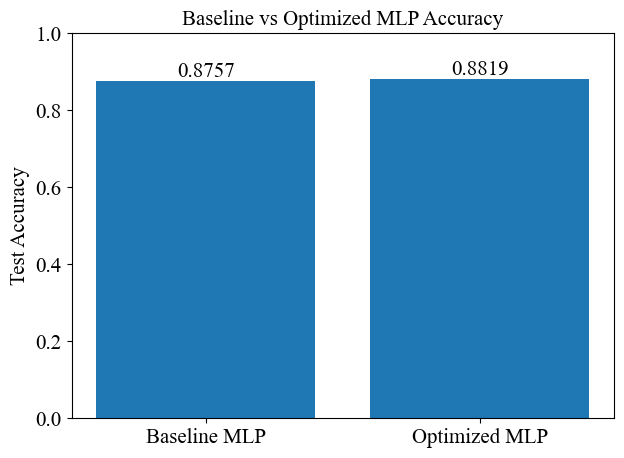

In [67]:
models = ["Baseline MLP", "Optimized MLP"]
accuracies = [
    baseline_accuracy,
    optimized_accuracy
]

plt.figure(figsize=(7, 5))

bars = plt.bar(models, accuracies)

plt.ylabel("Test Accuracy")
plt.title("Baseline vs Optimized MLP Accuracy")
plt.ylim(0, 1)

for bar, value in zip(bars, accuracies):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        value + 0.01,
        f"{value:.4f}",
        ha="center"
    )
plt.savefig(
    "baseline_vs_optimised_mlp_acc.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()

In [50]:
# The plot directly compares the test accuracy of the baseline and optimized MLP. The result indicates whether automated hyperparameter selection provides an improvement over the manually configured baseline model.

In [52]:
best_parameters_table = pd.DataFrame({
    "Hyperparameter": [
        "Hidden Layers",
        "Hidden Neurons",
        "Learning Rate",
        "Batch Size",
        "Optimizer",
        "Activation Function",
        "Epochs",
        "Dropout",
        "Cross-validation Accuracy",
        "Testing Accuracy"
    ],
    "Best Value": [
        2,
        f"{best_neurons1}, {best_neurons2}",
        best_lr,
        best_batch_size,
        best_optimizer,
        best_activation,
        best_epochs,
        best_dropout,
        best,
        optimized_accuracy
    ]
})

best_parameters_table

,Hyperparameter,Best Value
0,Hidden Layers,2
1,Hidden Neurons,"256, 64"
2,Learning Rate,0.0005
3,Batch Size,32
4,Optimizer,Adam
5,Activation Function,ReLU
6,Epochs,20
7,Dropout,0.2
8,Cross-validation Accuracy,"{'batch_size': 32, 'epochs': 20, 'model__dropo..."
9,Testing Accuracy,0.8819


In [53]:
# additional exs

In [54]:


# XOR truth table
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_xor = np.array([0, 1, 1, 0])

print("XOR Dataset")
print("X1 X2 | Y")

for x, y in zip(X_xor, y_xor):
    print(int(x[0]), int(x[1]), "|", y)

XOR Dataset
X1 X2 | Y
0 0 | 0
0 1 | 1
1 0 | 1
1 1 | 0


In [55]:
def step_function(z):
    return 1 if z >= 0 else 0

In [61]:
def plot_decision_boundary(X, y, weights, bias, update_no):
    plt.figure(figsize=(5, 4))

    # Plot XOR samples
    for label in [0, 1]:
        points = X[y == label]

        plt.scatter(
            points[:, 0],
            points[:, 1],
            label=f"Class {label}",
            s=100
        )

    # Decision boundary:
    # w1*x1 + w2*x2 + b = 0

    x_values = np.linspace(-0.5, 1.5, 100)

    if abs(weights[1]) > 1e-8:
        y_values = -(
            weights[0] * x_values + bias
        ) / weights[1]

        plt.plot(
            x_values,
            y_values,
            label="Decision Boundary"
        )

    elif abs(weights[0]) > 1e-8:
        x_boundary = -bias / weights[0]

        plt.axvline(
            x=x_boundary,
            label="Decision Boundary"
        )

    plt.xlim(-0.5, 1.5)
    plt.ylim(-0.5, 1.5)

    plt.xlabel("X1")
    plt.ylabel("X2")

    plt.title(
        f"Decision Boundary After Update {update_no}\n"
        f"W = {np.round(weights, 2)}, b = {bias:.2f}"
    )

    plt.legend()
    plt.grid(True)
    plt.savefig(
        f"xor_update_{update_no}.eps",
        format="eps",
        dpi=600,
        bbox_inches="tight"
    )
    plt.show()


========== EPOCH 1 ==========
Input=[0 0], Target=0, Prediction=1, Error=-1
  --> Update 1: W1=0.00, W2=0.00, Bias=-0.10


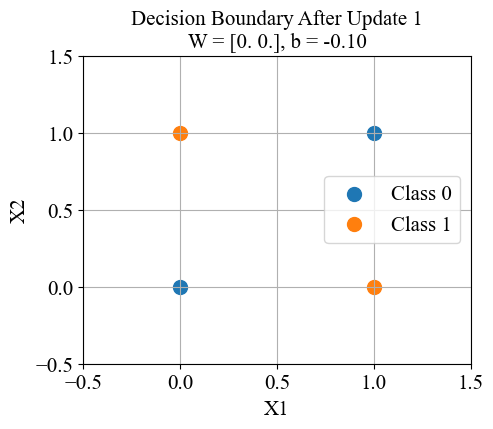

Input=[0 1], Target=1, Prediction=0, Error=1
  --> Update 2: W1=0.00, W2=0.10, Bias=0.00


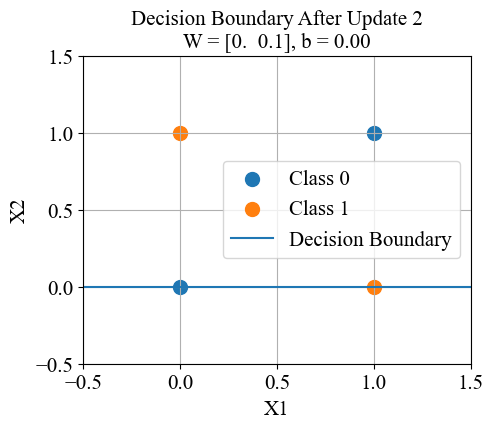

Input=[1 0], Target=1, Prediction=1, Error=0
Input=[1 1], Target=0, Prediction=1, Error=-1
  --> Update 3: W1=-0.10, W2=0.00, Bias=-0.10


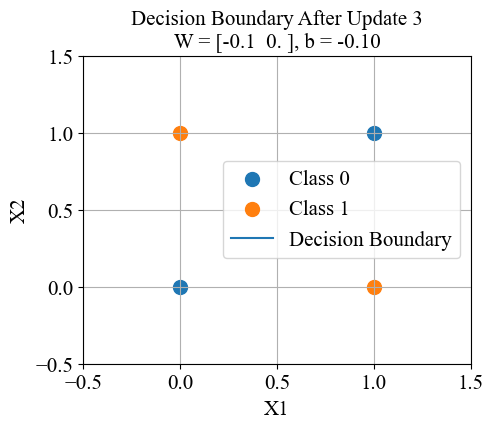

Errors in Epoch 1: 3

========== EPOCH 2 ==========
Input=[0 0], Target=0, Prediction=0, Error=0
Input=[0 1], Target=1, Prediction=0, Error=1
  --> Update 4: W1=-0.10, W2=0.10, Bias=0.00


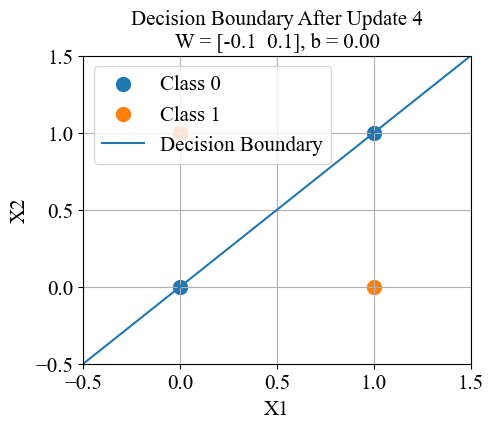

Input=[1 0], Target=1, Prediction=0, Error=1
  --> Update 5: W1=0.00, W2=0.10, Bias=0.10


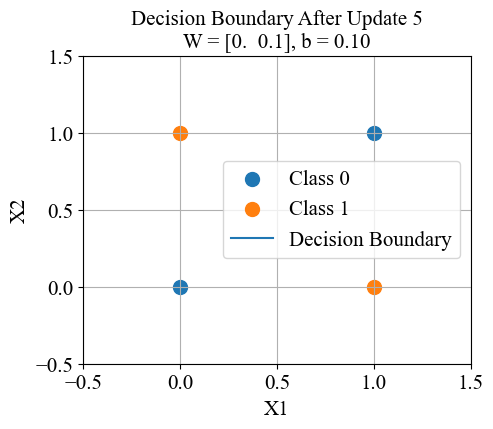

Input=[1 1], Target=0, Prediction=1, Error=-1
  --> Update 6: W1=-0.10, W2=0.00, Bias=0.00


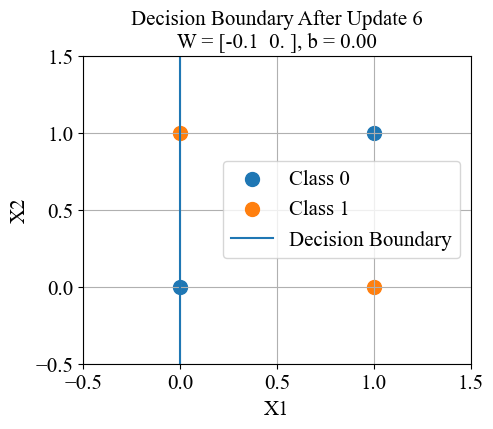

Errors in Epoch 2: 3

========== EPOCH 3 ==========
Input=[0 0], Target=0, Prediction=1, Error=-1
  --> Update 7: W1=-0.10, W2=0.00, Bias=-0.10


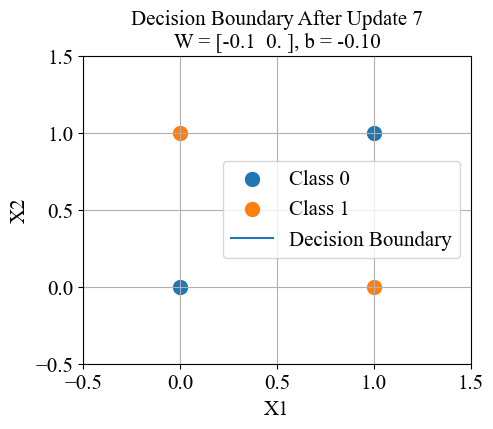

Input=[0 1], Target=1, Prediction=0, Error=1
  --> Update 8: W1=-0.10, W2=0.10, Bias=0.00


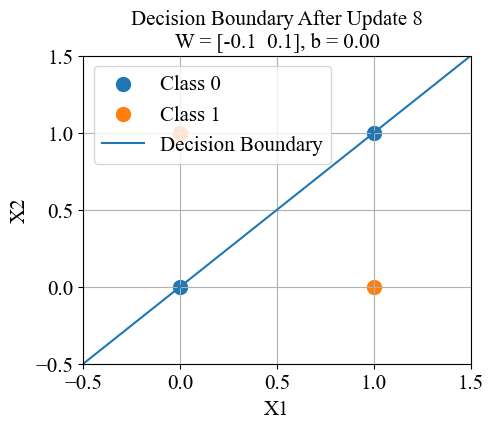

Input=[1 0], Target=1, Prediction=0, Error=1
  --> Update 9: W1=0.00, W2=0.10, Bias=0.10


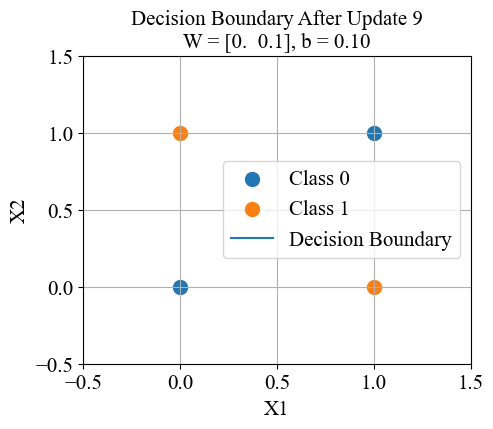

Input=[1 1], Target=0, Prediction=1, Error=-1
  --> Update 10: W1=-0.10, W2=0.00, Bias=0.00


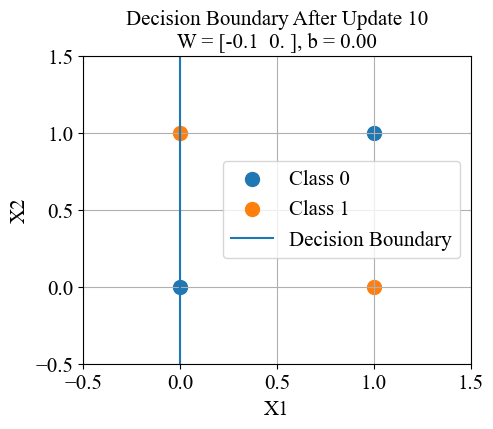

Errors in Epoch 3: 4

========== EPOCH 4 ==========
Input=[0 0], Target=0, Prediction=1, Error=-1
  --> Update 11: W1=-0.10, W2=0.00, Bias=-0.10


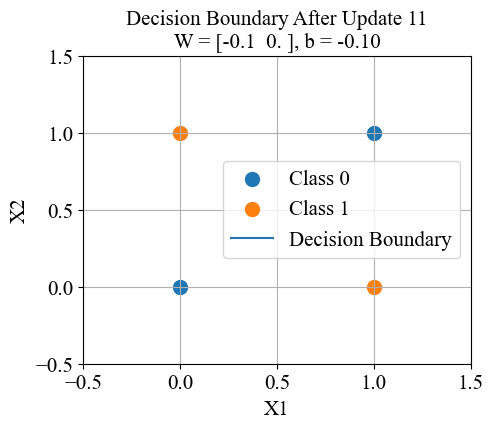

Input=[0 1], Target=1, Prediction=0, Error=1
  --> Update 12: W1=-0.10, W2=0.10, Bias=0.00


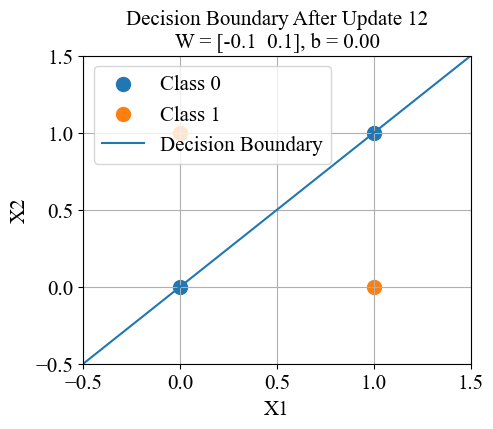

Input=[1 0], Target=1, Prediction=0, Error=1
  --> Update 13: W1=0.00, W2=0.10, Bias=0.10


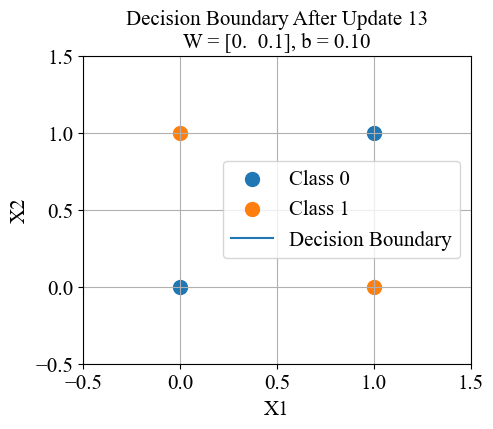

Input=[1 1], Target=0, Prediction=1, Error=-1
  --> Update 14: W1=-0.10, W2=0.00, Bias=0.00


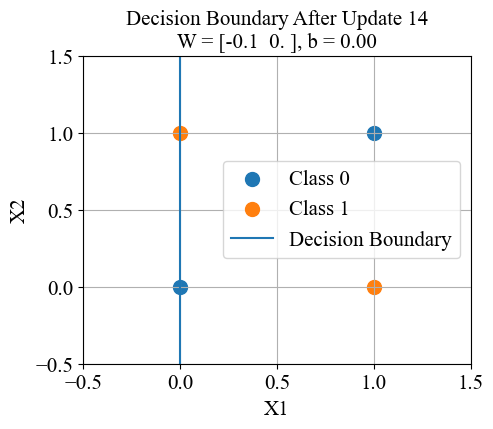

Errors in Epoch 4: 4

========== EPOCH 5 ==========
Input=[0 0], Target=0, Prediction=1, Error=-1
  --> Update 15: W1=-0.10, W2=0.00, Bias=-0.10


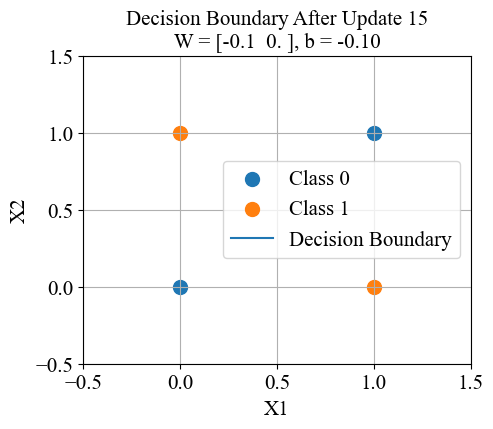

Input=[0 1], Target=1, Prediction=0, Error=1
  --> Update 16: W1=-0.10, W2=0.10, Bias=0.00


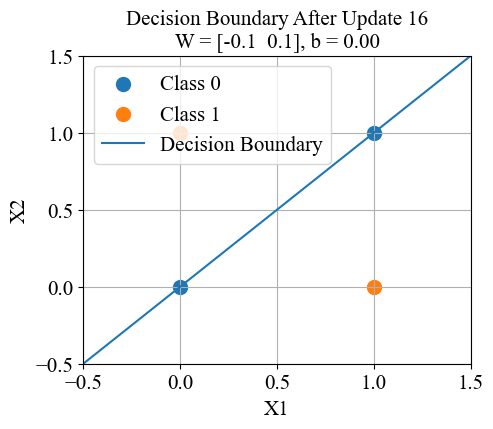

Input=[1 0], Target=1, Prediction=0, Error=1
  --> Update 17: W1=0.00, W2=0.10, Bias=0.10


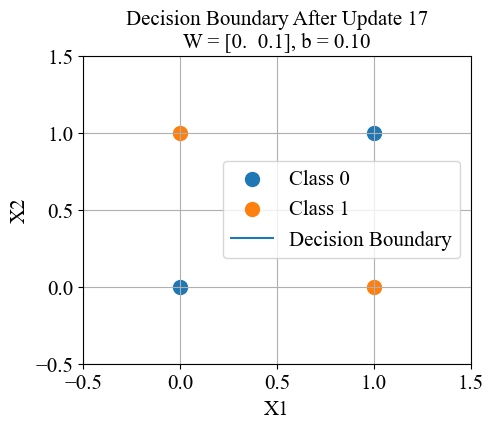

Input=[1 1], Target=0, Prediction=1, Error=-1
  --> Update 18: W1=-0.10, W2=0.00, Bias=0.00


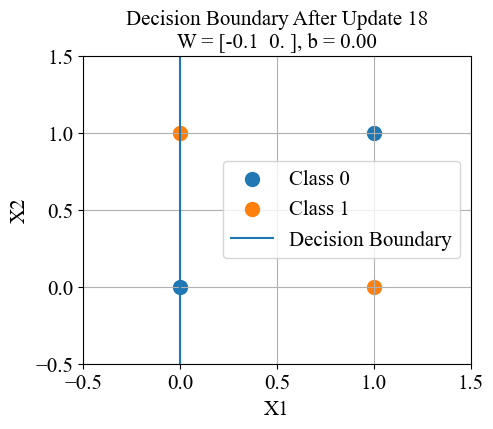

Errors in Epoch 5: 4

Perceptron did NOT converge within the specified epochs.


In [62]:
learning_rate = 0.1
max_epochs = 5

weights = np.zeros(2)
bias = 0.0

update_no = 0
update_history = []

for epoch in range(max_epochs):

    errors = 0

    print(f"\n========== EPOCH {epoch + 1} ==========")

    for i in range(len(X_xor)):

        x = X_xor[i]
        target = y_xor[i]

        # Forward propagation
        z = np.dot(weights, x) + bias
        prediction = step_function(z)

        error = target - prediction

        print(
            f"Input={x.astype(int)}, "
            f"Target={target}, "
            f"Prediction={prediction}, "
            f"Error={error}"
        )

        # Update only when misclassified
        if error != 0:

            errors += 1
            update_no += 1

            weights = weights + learning_rate * error * x
            bias = bias + learning_rate * error

            update_history.append({
                "Update": update_no,
                "Epoch": epoch + 1,
                "Input": x.copy(),
                "Error": error,
                "W1": weights[0],
                "W2": weights[1],
                "Bias": bias
            })

            print(
                f"  --> Update {update_no}: "
                f"W1={weights[0]:.2f}, "
                f"W2={weights[1]:.2f}, "
                f"Bias={bias:.2f}"
            )

            plot_decision_boundary(
                X_xor,
                y_xor,
                weights.copy(),
                bias,
                update_no
            )

    print(f"Errors in Epoch {epoch + 1}: {errors}")

    if errors == 0:
        print("\nPerceptron converged.")
        break

else:
    print(
        "\nPerceptron did NOT converge "
        "within the specified epochs."
    )

In [58]:
xor_update_df = pd.DataFrame(update_history)

xor_update_df

,Update,Epoch,Input,Error,W1,W2,Bias
0,1,1,"[0.0, 0.0]",-1,0.0,0.0,-0.1
1,2,1,"[0.0, 1.0]",1,0.0,0.1,0.0
2,3,1,"[1.0, 1.0]",-1,-0.1,0.0,-0.1
3,4,2,"[0.0, 1.0]",1,-0.1,0.1,0.0
4,5,2,"[1.0, 0.0]",1,0.0,0.1,0.1
5,6,2,"[1.0, 1.0]",-1,-0.1,0.0,0.0
6,7,3,"[0.0, 0.0]",-1,-0.1,0.0,-0.1
7,8,3,"[0.0, 1.0]",1,-0.1,0.1,0.0
8,9,3,"[1.0, 0.0]",1,0.0,0.1,0.1
9,10,3,"[1.0, 1.0]",-1,-0.1,0.0,0.0


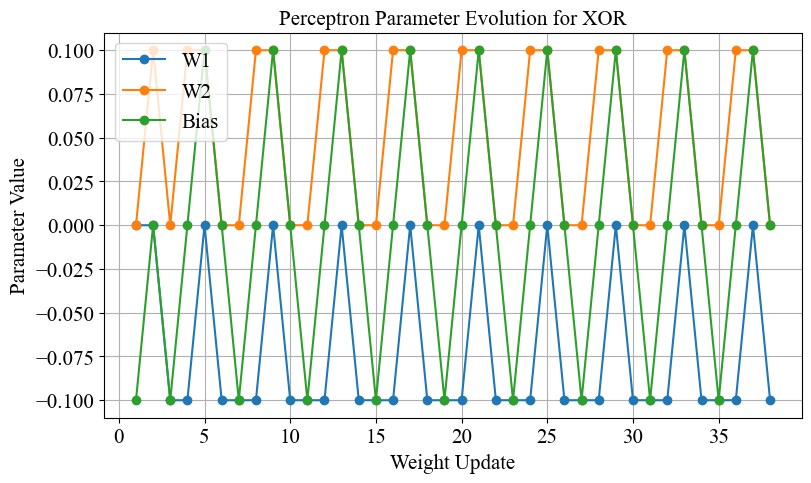

In [63]:
plt.figure(figsize=(9, 5))

plt.plot(
    xor_update_df["Update"],
    xor_update_df["W1"],
    marker="o",
    label="W1"
)

plt.plot(
    xor_update_df["Update"],
    xor_update_df["W2"],
    marker="o",
    label="W2"
)

plt.plot(
    xor_update_df["Update"],
    xor_update_df["Bias"],
    marker="o",
    label="Bias"
)

plt.xlabel("Weight Update")
plt.ylabel("Parameter Value")
plt.title("Perceptron Parameter Evolution for XOR")
plt.legend()
plt.grid(True)
plt.savefig(
    "xor_parameter_evolution.eps",
    format="eps",
    dpi=600,
    bbox_inches="tight"
)
plt.show()